### PCA and Regression Analysis of NWMP Water Sampling Data (Maharashtra)

Roll No: 23052120  
Dataset: July, August, September 2025 [(Link)](https://www.data.gov.in/catalog/nwmp-water-sampling-data-maharashtra)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error
import geopandas as gpd        # pip install geopandas
from shapely.geometry import Point  # ships with geopandas

## Step 0: Loading the Data

We have water quality readings from three different months — **July**, **August**, and **September**. The plan is simple:

- **July + August** → training set  
- **September** → test set  

After loading, we trim all three datasets to the columns they share (August and September carry one extra column), then combine July and August into a single training frame.

In [3]:
july = pd.read_csv("data/july.csv", encoding="latin1")
aug  = pd.read_csv("data/august.csv", encoding="latin1")
sep  = pd.read_csv("data/september.csv", encoding="latin1")

# Keep only the columns present in all three months
common_cols = july.columns.intersection(aug.columns).intersection(sep.columns)
july, aug, sep = july[common_cols], aug[common_cols], sep[common_cols]

# Combine July + August for training; September is our test set
train_raw = pd.concat([july, aug], ignore_index=True)
test_raw  = sep.copy()

print(f"Training set (Jul + Aug) : {train_raw.shape[0]} rows, {train_raw.shape[1]} columns")
print(f"Test set     (Sep)       : {test_raw.shape[0]} rows, {test_raw.shape[1]} columns")

Training set (Jul + Aug) : 444 rows, 52 columns
Test set     (Sep)       : 222 rows, 52 columns


## Step 1: Cleaning & Preprocessing

The raw dataset carries columns that aren't numeric measurements — things like station names, dates, and descriptive text. We drop those, then:

1. **Coerce to numeric** — anything that can't be parsed becomes `NaN`.  
2. **Drop sparse rows** — any row where more than half the values are missing is removed.  
3. **Fill remaining NaNs** — we use the column **median** (a robust choice for water-quality data, which can have outliers).  

Finally we **`StandardScaler`-normalise** the features so that PCA and regression treat every measurement unit equally.

In [4]:
# Columns that are identifiers / descriptive text — not useful as model features
drop_cols = [
    'STN Code', 'Sampling Date', 'Month', 'Sampling Time',
    'Stn Name', 'Type Water Body', 'Name Of Water Body',
    'River Basin', 'District', 'State Name', 'Mon Agency',
    'Frequency', 'Major Polluting Sources', 'Use Based Class',
    ' Visibility Effluent Discharge', 'Weather', 'Approx Depth',
    'Human Activities', 'Floating Matter', 'Color', 'Odor', 'Flow'
]

# Even roll no. → predict Potassium & Fluoride
TARGET_COLS = ['Potassium', 'Flouride']   # note the dataset spells it 'Flouride'

def prep(df):
    d = df.drop(columns=[c for c in drop_cols if c in df.columns], errors='ignore')
    d = d.apply(pd.to_numeric, errors='coerce')
    d = d.dropna(thresh=int(0.5 * d.shape[1]))   # drop rows with > 50 % missing
    d = d.fillna(d.median(numeric_only=True))     # fill the rest with column median
    return d

train = prep(train_raw)
test  = prep(test_raw)

# Restrict to columns present in both splits so feature sets match
shared      = train.columns.intersection(test.columns)
train, test = train[shared], test[shared]

# Everything except targets and lat/lon becomes a feature
feat_cols = [c for c in shared if c not in TARGET_COLS + ['latitude', 'longitude']]

X_train = train[feat_cols]
X_test  = test[feat_cols]

scaler   = StandardScaler()
Xs_train = scaler.fit_transform(X_train)
Xs_test  = scaler.transform(X_test)

print(f"Number of features : {len(feat_cols)}")
print(f"Target columns     : {TARGET_COLS}")
print(f"Training samples   : {X_train.shape[0]}")
print(f"Test samples       : {X_test.shape[0]}")

Number of features : 26
Target columns     : ['Potassium', 'Flouride']
Training samples   : 424
Test samples       : 221


## Task 1: Principal Component Analysis (PCA)

PCA finds the directions in our high-dimensional feature space that capture the most variance. We compress everything down to **2 principal components** so we can:

- **Scree plot** — see how many PCs it takes to explain most of the variance.  
- **2-D scatter** — visually check whether training (Jul+Aug) and test (Sep) samples overlap in the learned space, which gives us a sense of how well the model should generalise.

PC1 captures : 36.24% of variance
PC2 captures : 13.91% of variance
Together     : 50.16% of total variance


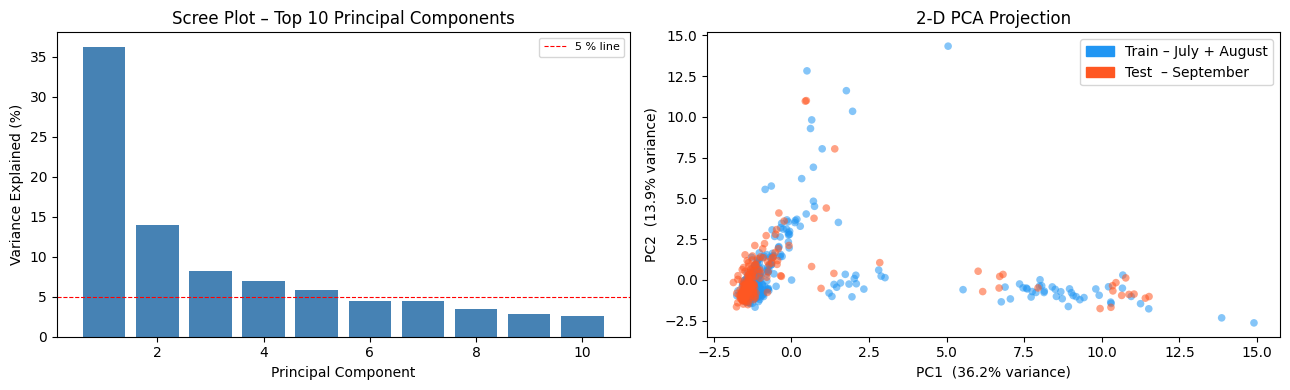

Saved → task1_pca.png


In [5]:
# Fit PCA on training data, then project both train and test into the same space
pca       = PCA(n_components=2)
pca_train = pca.fit_transform(Xs_train)
pca_test  = pca.transform(Xs_test)

explained = pca.explained_variance_ratio_
print(f"PC1 captures : {explained[0]*100:.2f}% of variance")
print(f"PC2 captures : {explained[1]*100:.2f}% of variance")
print(f"Together     : {sum(explained)*100:.2f}% of total variance")

# Fit a full PCA (no dimensionality limit) just to draw the scree plot
pca_full = PCA()
pca_full.fit(Xs_train)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── Left: Scree plot — how much does each PC contribute? ──────────────
axes[0].bar(range(1, 11), pca_full.explained_variance_ratio_[:10] * 100, color='steelblue')
axes[0].axhline(y=5, color='red', linestyle='--', linewidth=0.8, label='5 % line')
axes[0].set(title="Scree Plot – Top 10 Principal Components",
            xlabel="Principal Component", ylabel="Variance Explained (%)")
axes[0].legend(fontsize=8)

# ── Right: 2-D scatter — do train and test live in the same region? ───
colors  = ['#2196F3'] * len(pca_train) + ['#FF5722'] * len(pca_test)
all_pca = np.vstack([pca_train, pca_test])
axes[1].scatter(all_pca[:, 0], all_pca[:, 1], c=colors, alpha=0.55, s=30, edgecolors='none')
p1 = mpatches.Patch(color='#2196F3', label='Train – July + August')
p2 = mpatches.Patch(color='#FF5722', label='Test  – September')
axes[1].legend(handles=[p1, p2])
axes[1].set(title="2-D PCA Projection",
            xlabel=f"PC1  ({explained[0]*100:.1f}% variance)",
            ylabel=f"PC2  ({explained[1]*100:.1f}% variance)")

plt.tight_layout()
plt.savefig("task1_pca.png", dpi=150)
plt.show()
print("Saved → task1_pca.png")

## Task 2: Linear vs. Logistic Regression (Even Roll No.)

We predict **Potassium** and **Fluoride** concentrations using two approaches and compare their errors on the September test set.

| Model | What it predicts | Error metric |
|---|---|---|
| **Linear Regression** | Raw concentration value | MSE on continuous predictions |
| **Logistic Regression** | *High / Low* class (split at training-set median) | MSE of predicted probability vs. binary label |

Training is done on July + August; evaluation on September.


───────────────────────────────────────────────────────
  Target : Potassium   (Logistic split at median = 3.600)
  Linear   →  Train MSE : 943.3717   |  Test MSE : 1385.8884
  Logistic →  Train MSE : 0.1452   |  Test MSE : 0.2818


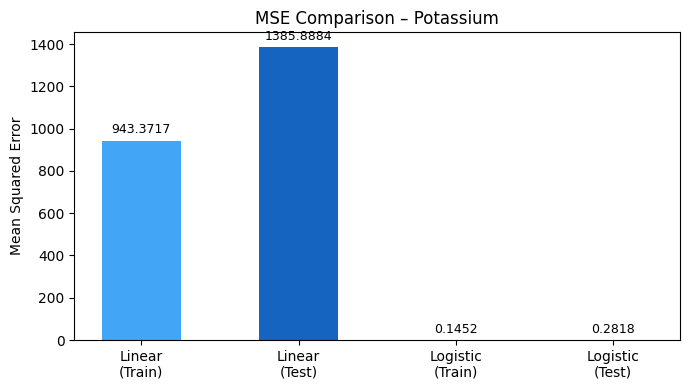

  Saved → task2_mse_potassium.png


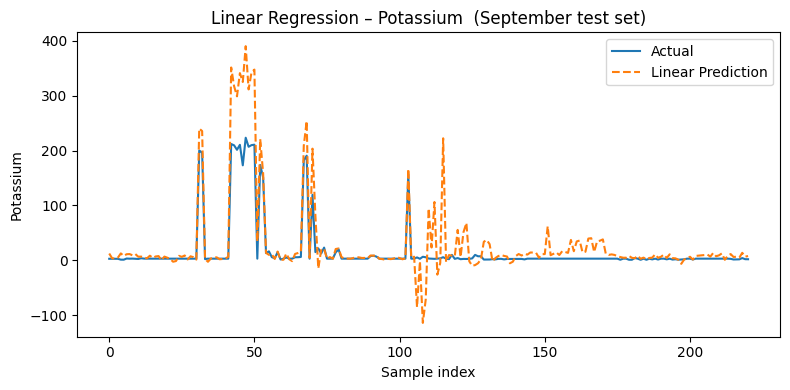

  Saved → task2_pred_potassium.png

───────────────────────────────────────────────────────
  Target : Flouride   (Logistic split at median = 0.510)
  Linear   →  Train MSE : 0.0291   |  Test MSE : 0.2165
  Logistic →  Train MSE : 0.1429   |  Test MSE : 0.5141


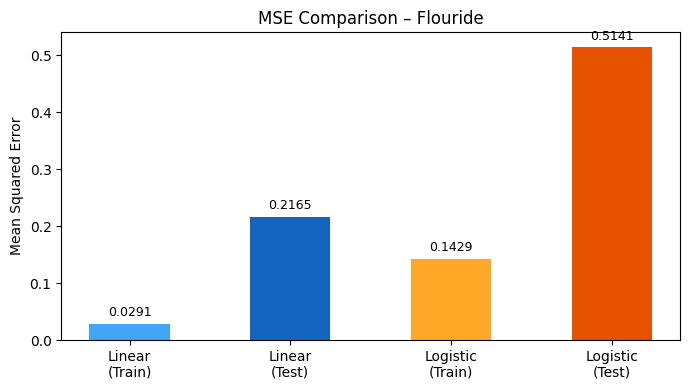

  Saved → task2_mse_flouride.png


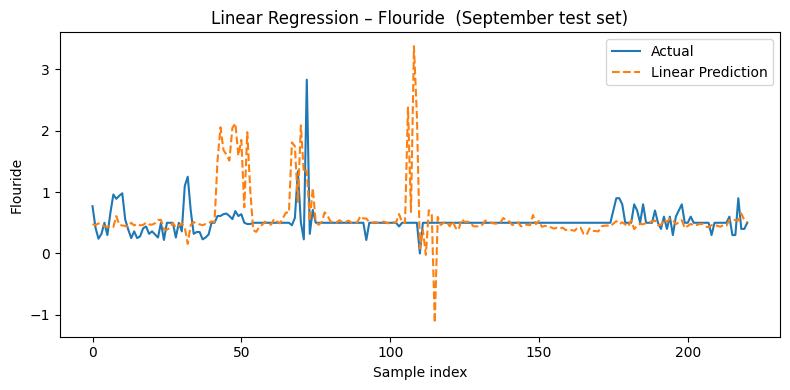

  Saved → task2_pred_flouride.png


In [6]:
results = {}

for target in TARGET_COLS:
    if target not in train.columns:
        print(f"  {target} not found in dataset, skipping.")
        continue

    y_tr = train[target]
    y_te = test[target]

    # ── Linear Regression: predict the raw concentration value ────────
    lr = LinearRegression()
    lr.fit(Xs_train, y_tr)
    y_pred_lr_train = lr.predict(Xs_train)
    y_pred_lr_test  = lr.predict(Xs_test)

    mse_lr_train = mean_squared_error(y_tr, y_pred_lr_train)
    mse_lr_test  = mean_squared_error(y_te, y_pred_lr_test)

    # ── Logistic Regression: classify each reading as High / Low ──────
    # We define "High" as anything at or above the training-set median
    threshold = y_tr.median()
    y_tr_bin  = (y_tr >= threshold).astype(int)
    y_te_bin  = (y_te >= threshold).astype(int)

    log_reg = LogisticRegression(max_iter=500)
    log_reg.fit(Xs_train, y_tr_bin)
    y_prob_log_train = log_reg.predict_proba(Xs_train)[:, 1]
    y_prob_log_test  = log_reg.predict_proba(Xs_test)[:, 1]

    # MSE: predicted probability vs. true binary label
    mse_log_train = mean_squared_error(y_tr_bin, y_prob_log_train)
    mse_log_test  = mean_squared_error(y_te_bin, y_prob_log_test)

    results[target] = dict(
        linear_train_mse=mse_lr_train,    linear_test_mse=mse_lr_test,
        logistic_train_mse=mse_log_train, logistic_test_mse=mse_log_test,
        threshold=threshold
    )

    print(f"\n{'─'*55}")
    print(f"  Target : {target}   (Logistic split at median = {threshold:.3f})")
    print(f"  Linear   →  Train MSE : {mse_lr_train:.4f}   |  Test MSE : {mse_lr_test:.4f}")
    print(f"  Logistic →  Train MSE : {mse_log_train:.4f}   |  Test MSE : {mse_log_test:.4f}")

    # ── Bar chart: side-by-side MSE comparison ────────────────────────
    fig, ax = plt.subplots(figsize=(7, 4))
    labels  = ['Linear\n(Train)', 'Linear\n(Test)', 'Logistic\n(Train)', 'Logistic\n(Test)']
    vals    = [mse_lr_train, mse_lr_test, mse_log_train, mse_log_test]
    colors2 = ['#42A5F5', '#1565C0', '#FFA726', '#E65100']
    bars    = ax.bar(labels, vals, color=colors2, width=0.5)
    ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)
    ax.set(title=f"MSE Comparison – {target}", ylabel="Mean Squared Error")
    plt.tight_layout()
    fname = f"task2_mse_{target.lower()}.png"
    plt.savefig(fname, dpi=150)
    plt.show()
    print(f"  Saved → {fname}")

    # ── Line chart: actual vs. linear-predicted on test set ───────────
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(y_te.values,       label='Actual',            linewidth=1.5)
    ax.plot(y_pred_lr_test,    label='Linear Prediction', linewidth=1.5, linestyle='--')
    ax.set(title=f"Linear Regression – {target}  (September test set)",
           xlabel="Sample index", ylabel=target)
    ax.legend()
    plt.tight_layout()
    fname2 = f"task2_pred_{target.lower()}.png"
    plt.savefig(fname2, dpi=150)
    plt.show()
    print(f"  Saved → {fname2}")

## Task 3: Geographic Map of Monitoring Stations (GeoPandas)

Every sampling station has a **latitude** and **longitude**. We use GeoPandas to plot those points on a map of India and colour them by chemical concentration — this gives an at-a-glance picture of spatial patterns across Maharashtra.

We use **all three months' data** for the map (more points = richer spatial picture).

Shapefile not found — plotting points on a blank canvas.


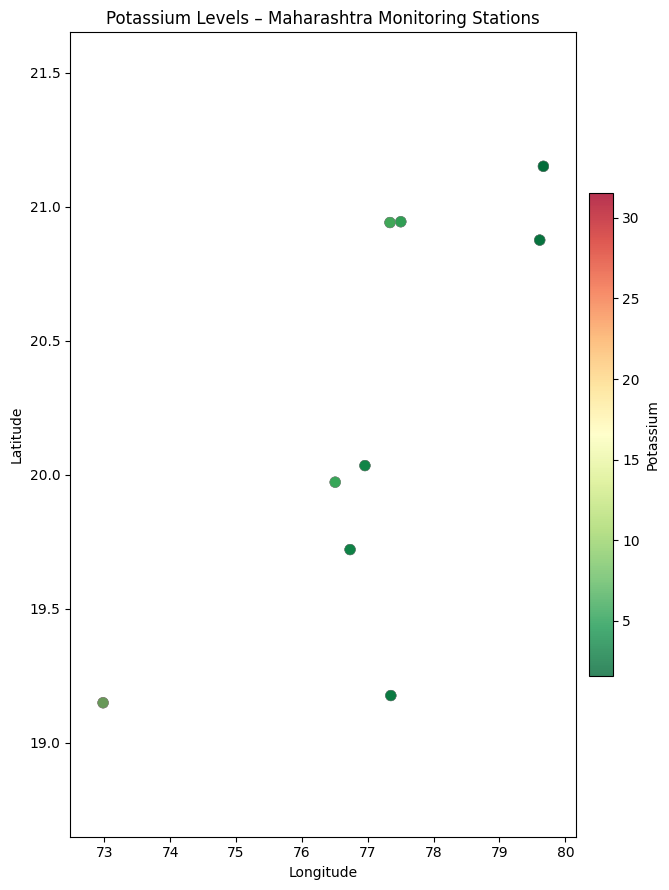

  Saved → task3_map_potassium.png


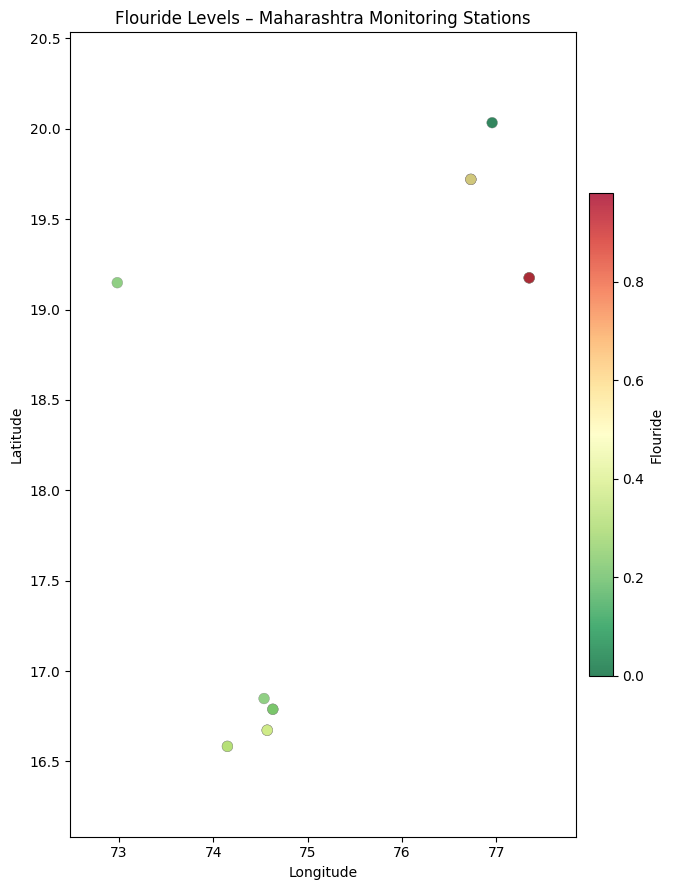

  Saved → task3_map_flouride.png


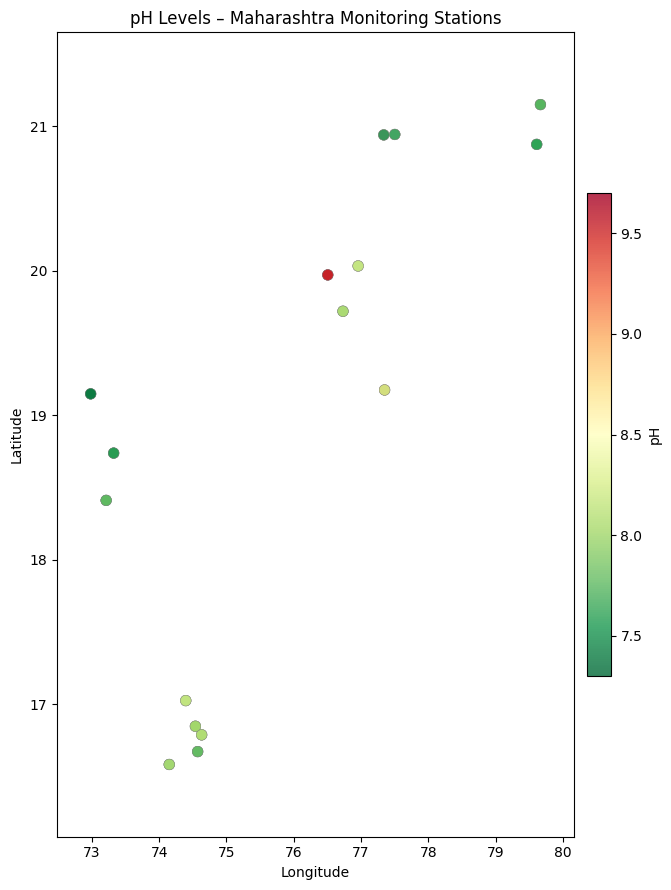

  Saved → task3_map_ph.png


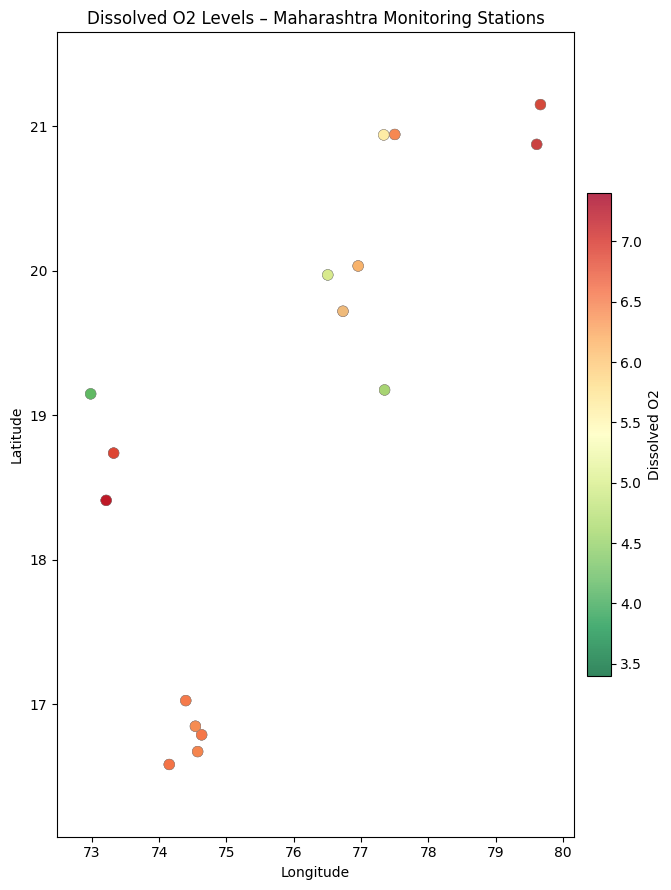

  Saved → task3_map_dissolved_o2.png


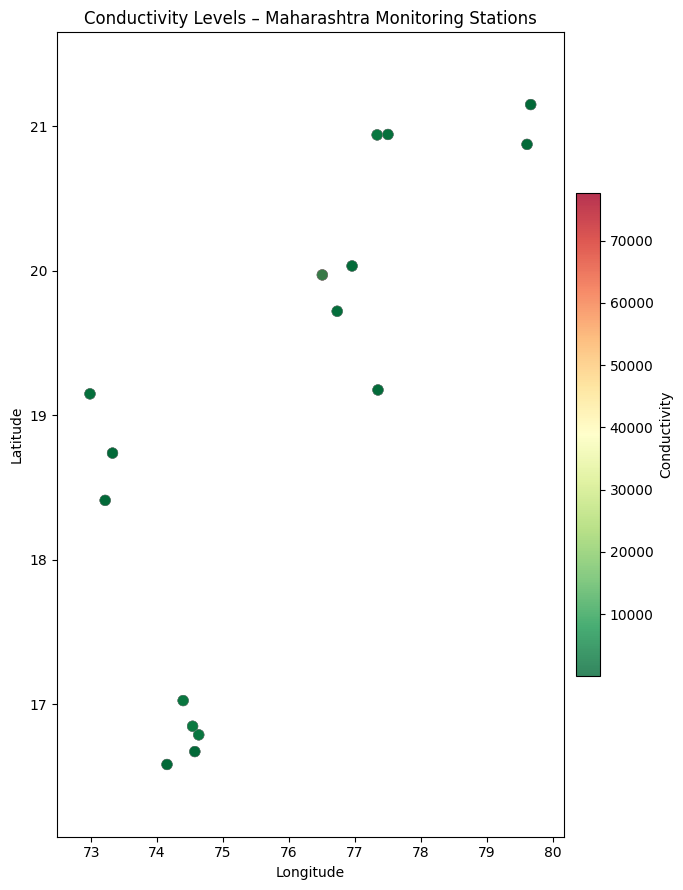

  Saved → task3_map_conductivity.png


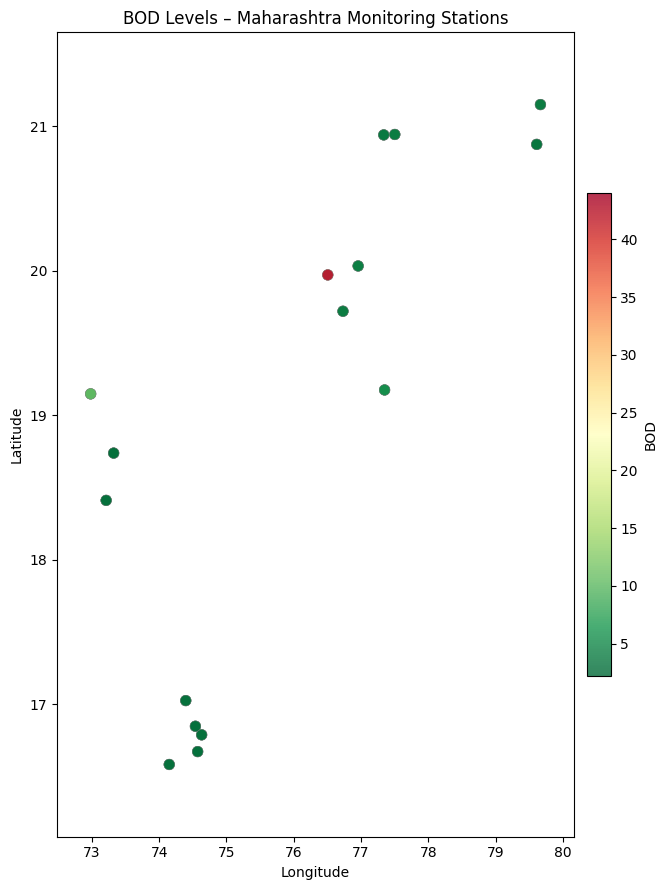

  Saved → task3_map_bod.png


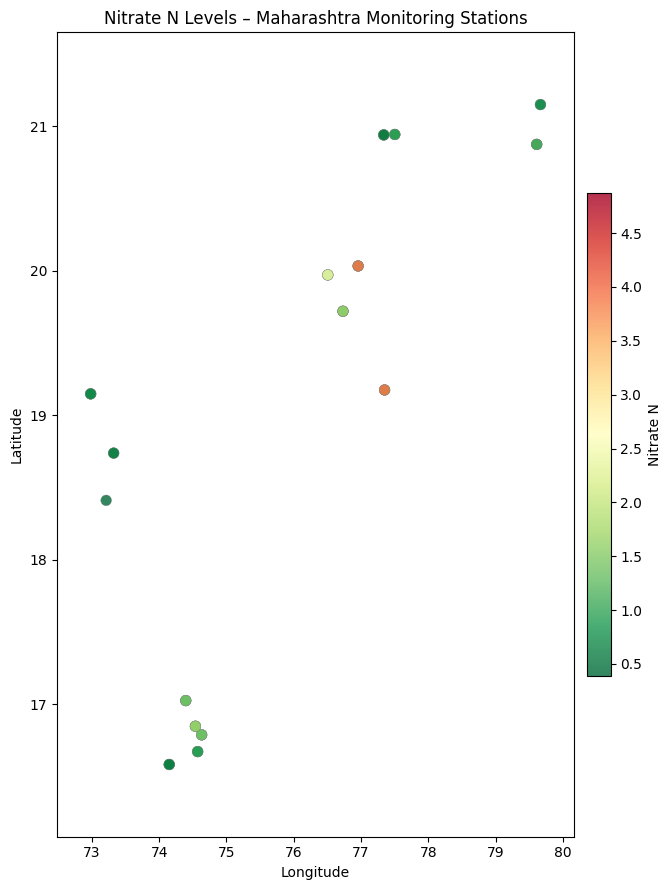

  Saved → task3_map_nitrate_n.png


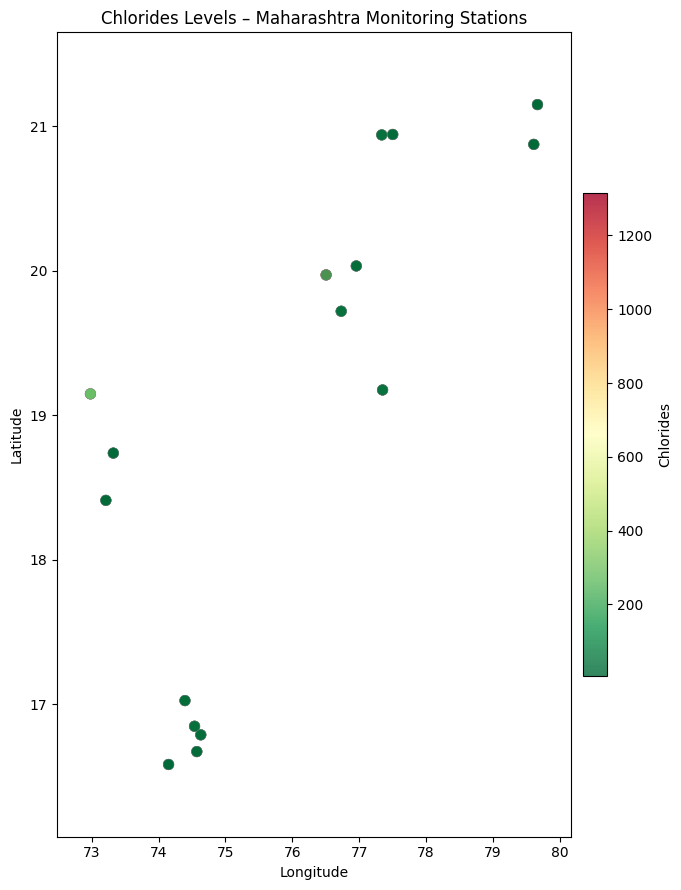

  Saved → task3_map_chlorides.png

All three tasks complete!


In [7]:
# Merge all three months for a fuller picture of spatial coverage
full_raw = pd.concat([july, aug, sep], ignore_index=True)

# Convert everything possible to numeric, but leave name/ID columns as-is
full_raw = full_raw.apply(
    lambda col: pd.to_numeric(col, errors='coerce')
    if col.name not in ['STN Code', 'Stn Name', 'State Name', 'District']
    else col
)

# We can only plot stations that have valid coordinates
map_df = full_raw.dropna(subset=['latitude', 'longitude']).copy()

# Load a built-in world shapefile from GeoPandas (low-res but perfectly fine)
try:
    world     = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
    india     = world[world.name == "India"]
    USE_SHAPE = True
except Exception:
    USE_SHAPE = False
    print("Shapefile not found — plotting points on a blank canvas.")

# Chemical parameters we want to visualise spatially
elements_to_map = ['Potassium', 'Flouride', 'pH', 'Dissolved O2',
                   'Conductivity', 'BOD', 'Nitrate N', 'Chlorides']
elements_to_map = [e for e in elements_to_map if e in map_df.columns]

for elem in elements_to_map:
    sub = map_df.dropna(subset=[elem, 'latitude', 'longitude'])
    if sub.empty:
        print(f"  No valid data for {elem}, skipping.")
        continue

    fig, ax = plt.subplots(figsize=(7, 9))

    if USE_SHAPE:
        india.boundary.plot(ax=ax, linewidth=0.8, color='#555')
        ax.set_xlim(72.5, 81.0)   # approximate longitude bounds for Maharashtra
        ax.set_ylim(15.5, 22.5)   # approximate latitude  bounds for Maharashtra
    else:
        ax.set_xlim(sub.longitude.min() - 0.5, sub.longitude.max() + 0.5)
        ax.set_ylim(sub.latitude.min()  - 0.5, sub.latitude.max()  + 0.5)

    sc = ax.scatter(
        sub['longitude'], sub['latitude'],
        c=sub[elem], cmap='RdYlGn_r',
        s=60, alpha=0.8, edgecolors='grey', linewidths=0.3
    )
    cbar = plt.colorbar(sc, ax=ax, shrink=0.6, pad=0.02)
    cbar.set_label(elem)
    ax.set(title=f"{elem} Levels – Maharashtra Monitoring Stations",
           xlabel="Longitude", ylabel="Latitude")
    plt.tight_layout()
    fname = f"task3_map_{elem.lower().replace(' ', '_')}.png"
    plt.savefig(fname, dpi=150)
    plt.show()
    print(f"  Saved → {fname}")

print("\nAll three tasks complete!")